In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [27]:
df = pd.read_csv("personality_dataset.csv")

In [28]:
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert
...,...,...,...,...,...,...,...,...
4995,5,No,6,5,No,14,8,Extrovert
4996,7,No,2,3,Yes,2,5,Introvert
4997,2,No,7,3,No,11,3,Extrovert
4998,2,Yes,9,3,No,15,7,Extrovert


In [29]:
from autoviz.AutoViz_Class import AutoViz_Class

In [30]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [31]:
AV = AutoViz_Class()

Shape of your Data Set loaded: (5000, 8)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  5
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  3
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    8 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
To fix these data quality issues in the dataset, import FixDQ from autoviz...
There are 128 dup

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Time_spent_Alone,int64,0.000000,0,0.000000,11.000000,No issue
Stage_fear,object,0.000000,0,,,No issue
Social_event_attendance,int64,0.000000,0,0.000000,10.000000,No issue
Going_outside,int64,0.000000,0,0.000000,7.000000,No issue
Drained_after_socializing,object,0.000000,0,,,No issue
Friends_circle_size,int64,0.000000,0,0.000000,15.000000,No issue
Post_frequency,int64,0.000000,0,0.000000,10.000000,No issue
Personality,object,0.000000,0,,,No issue


Number of All Scatter Plots = 15


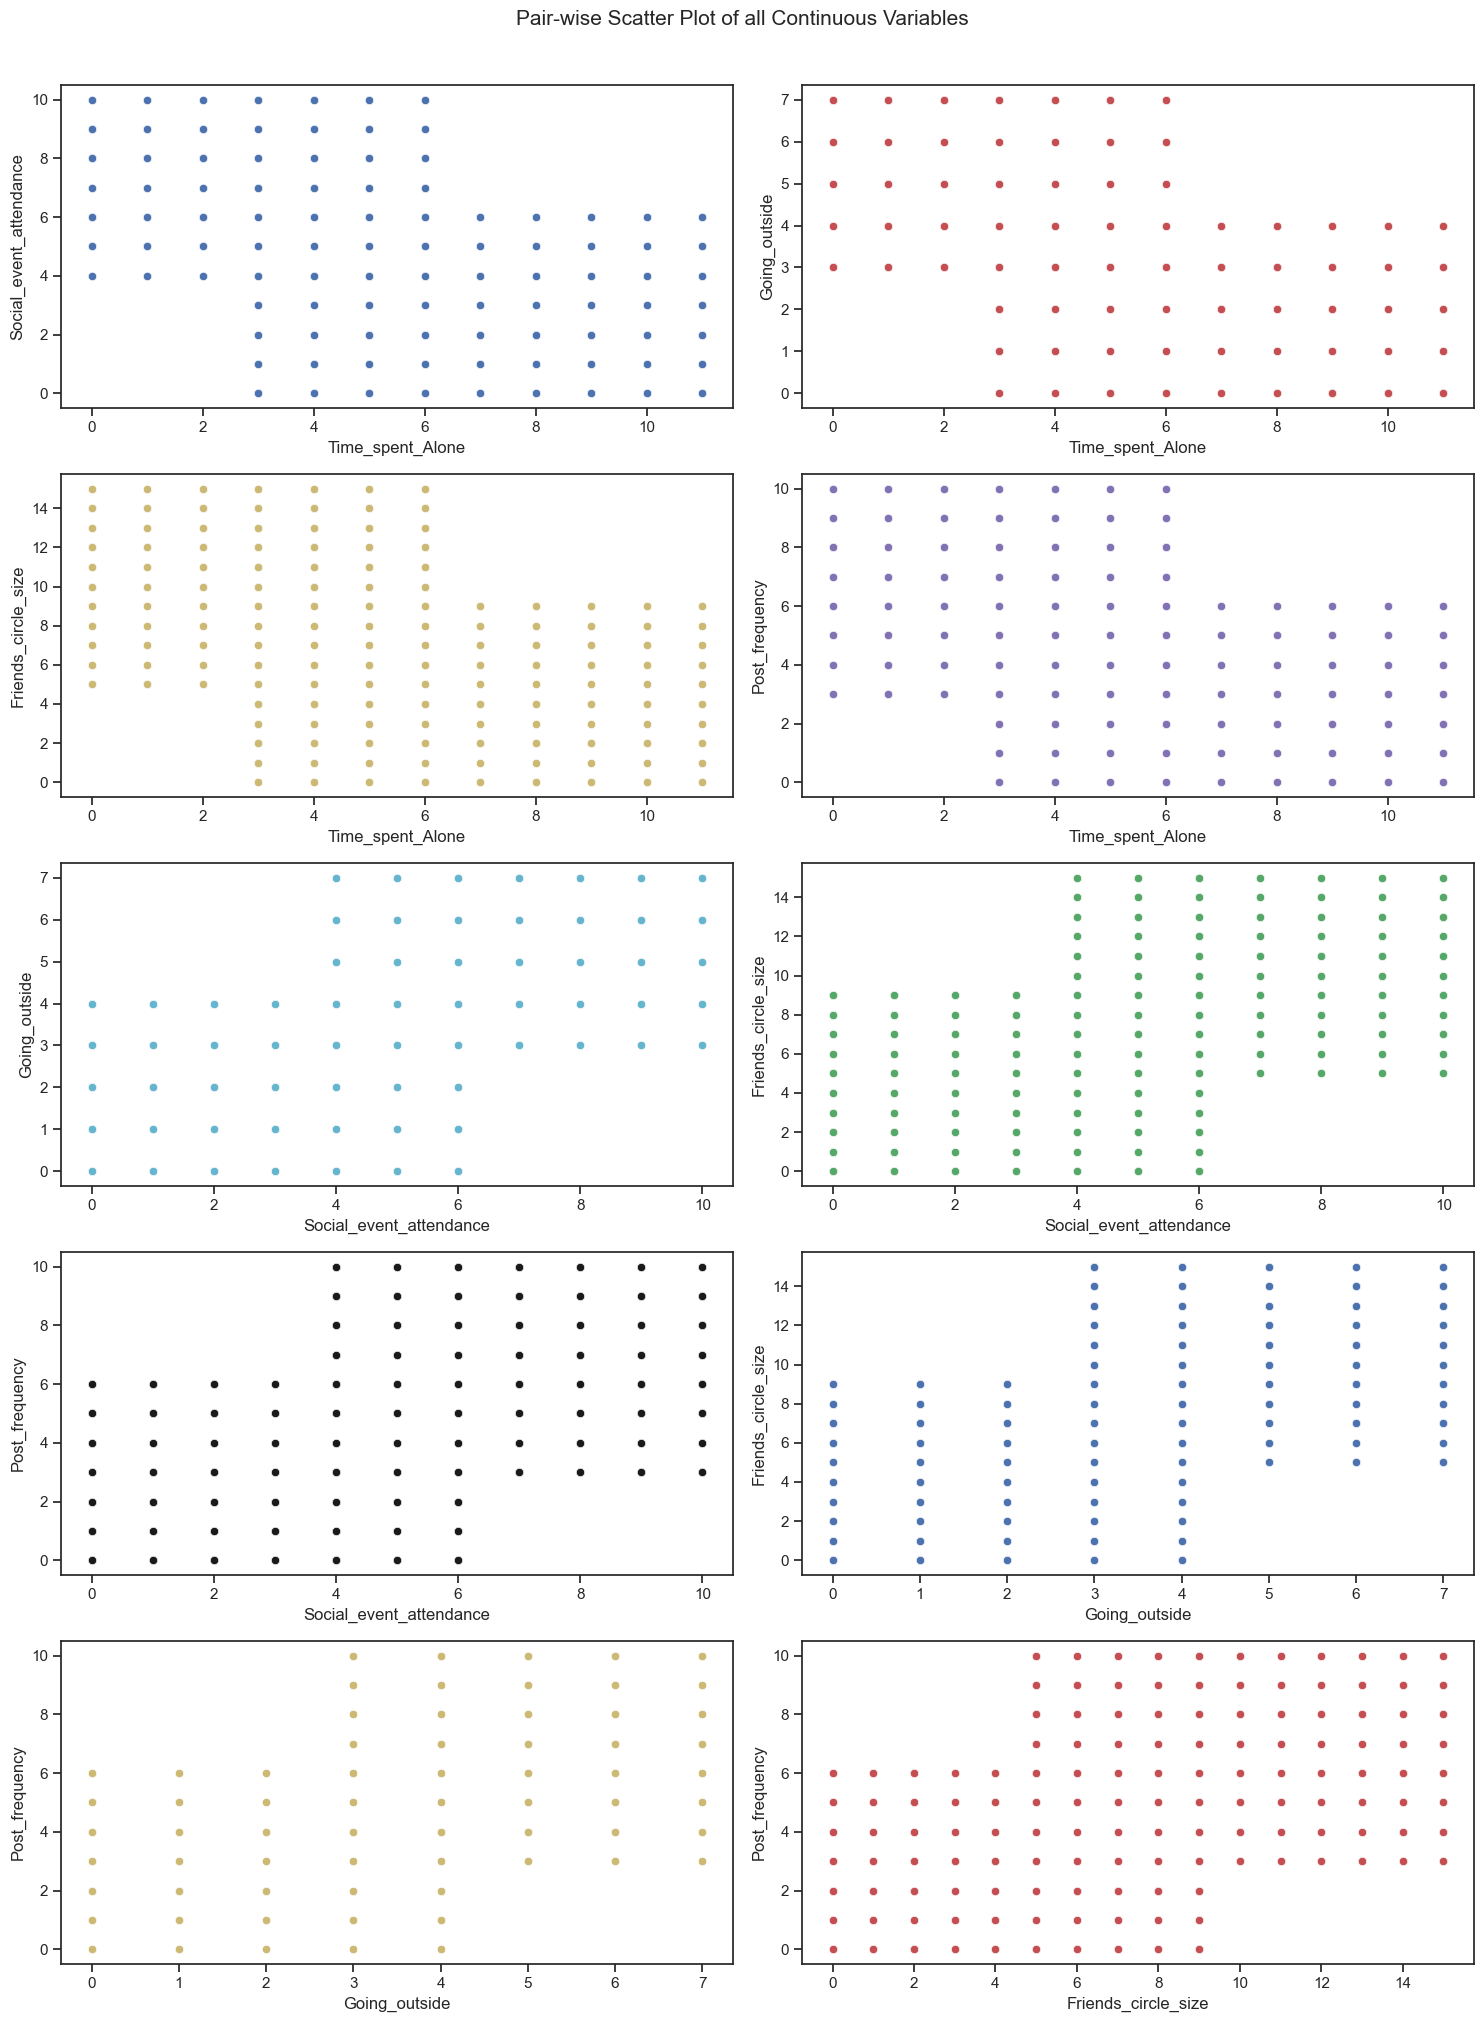

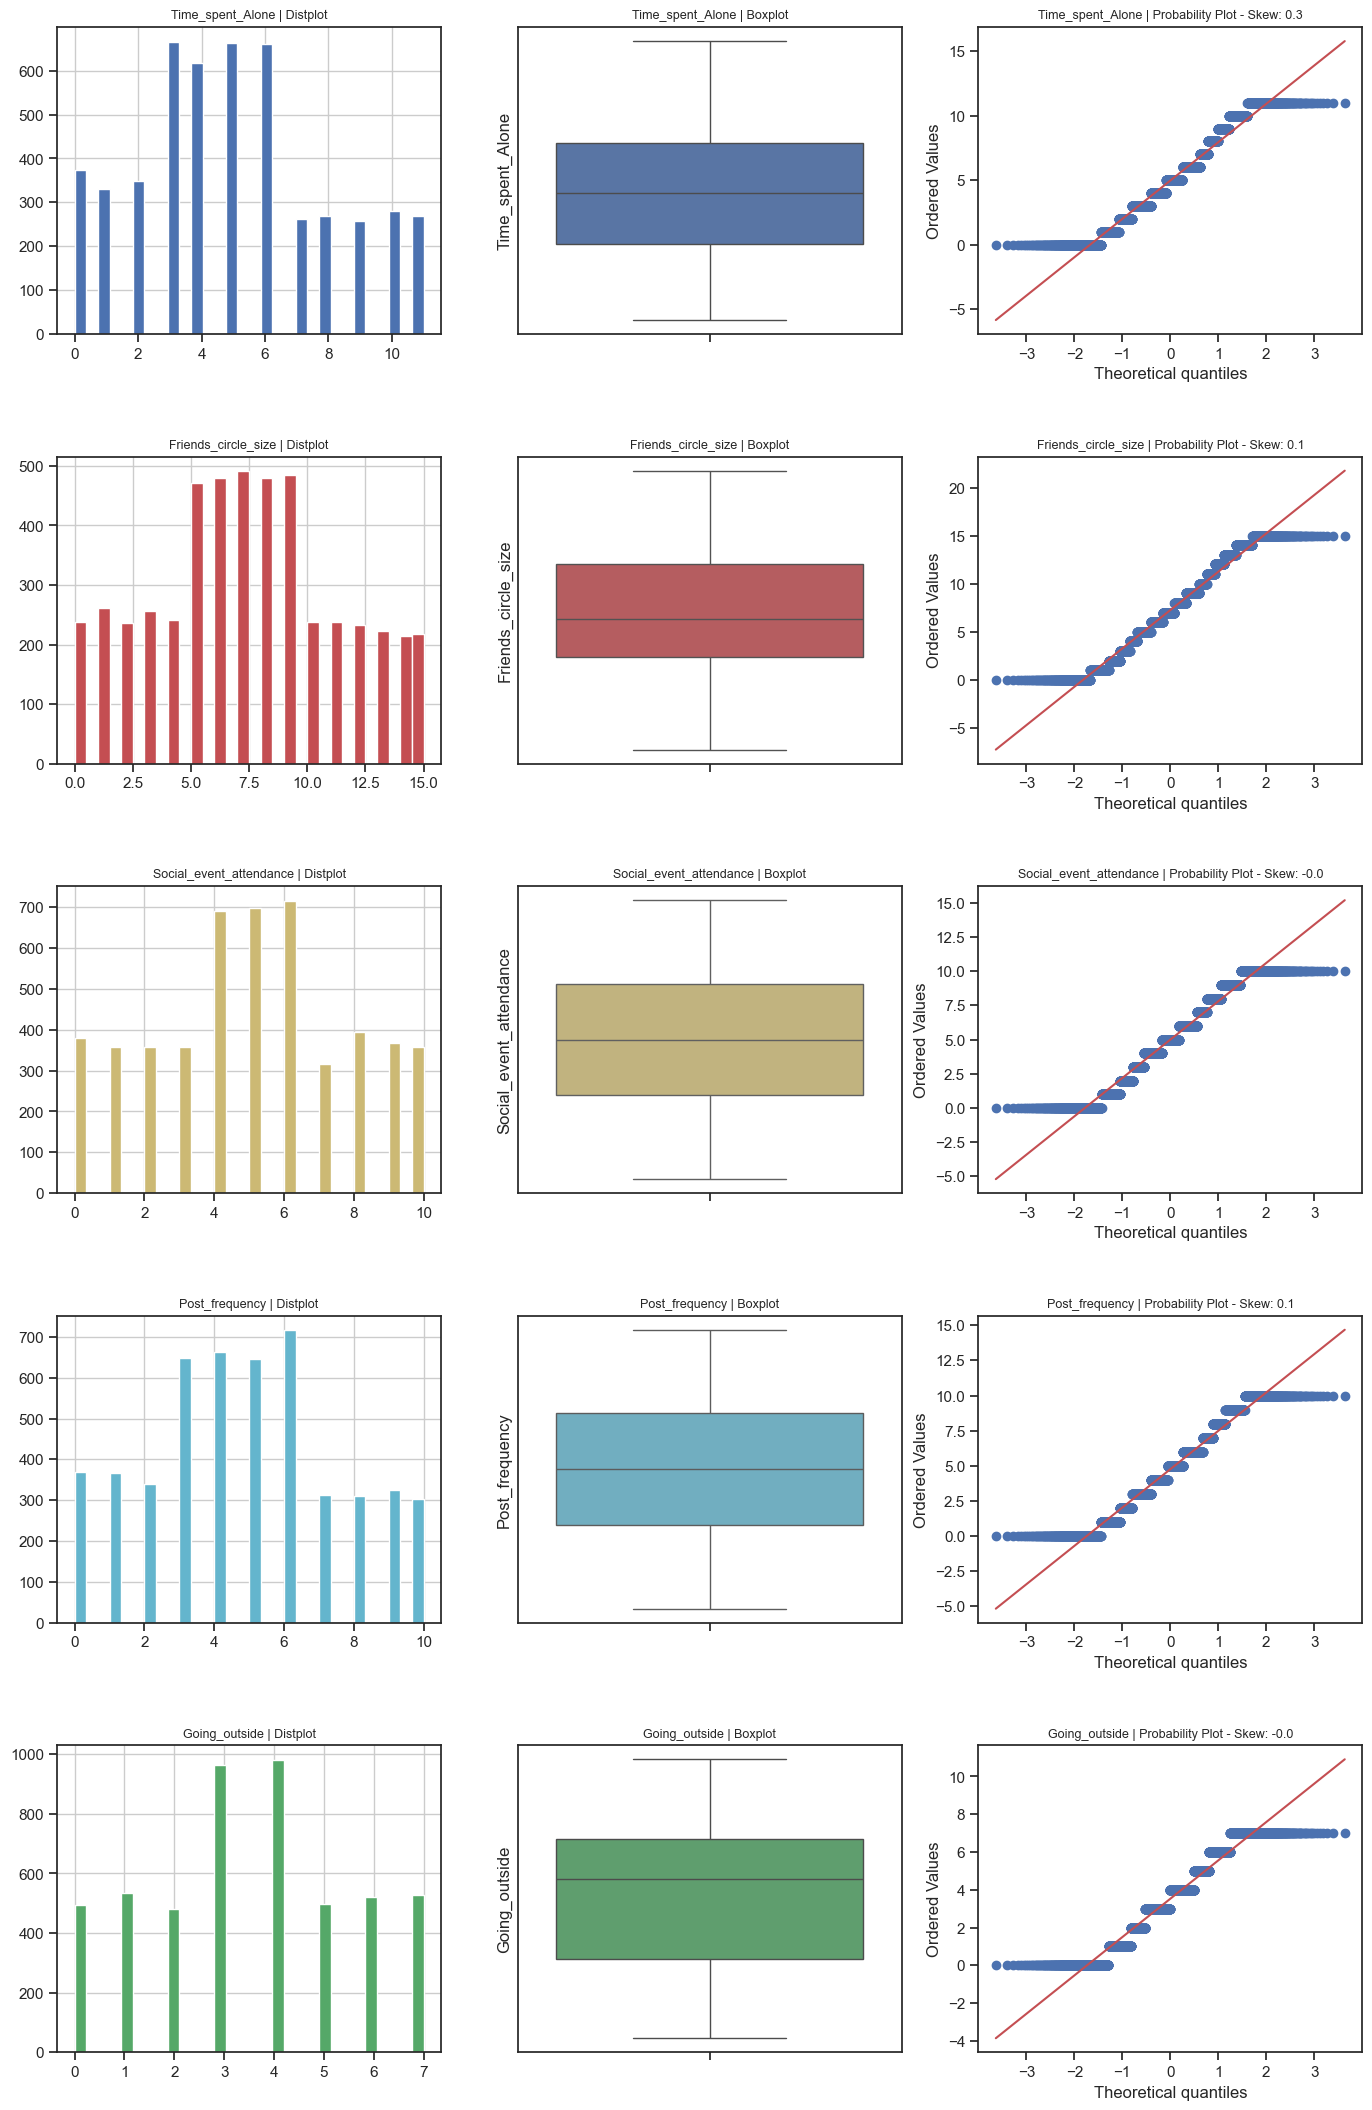

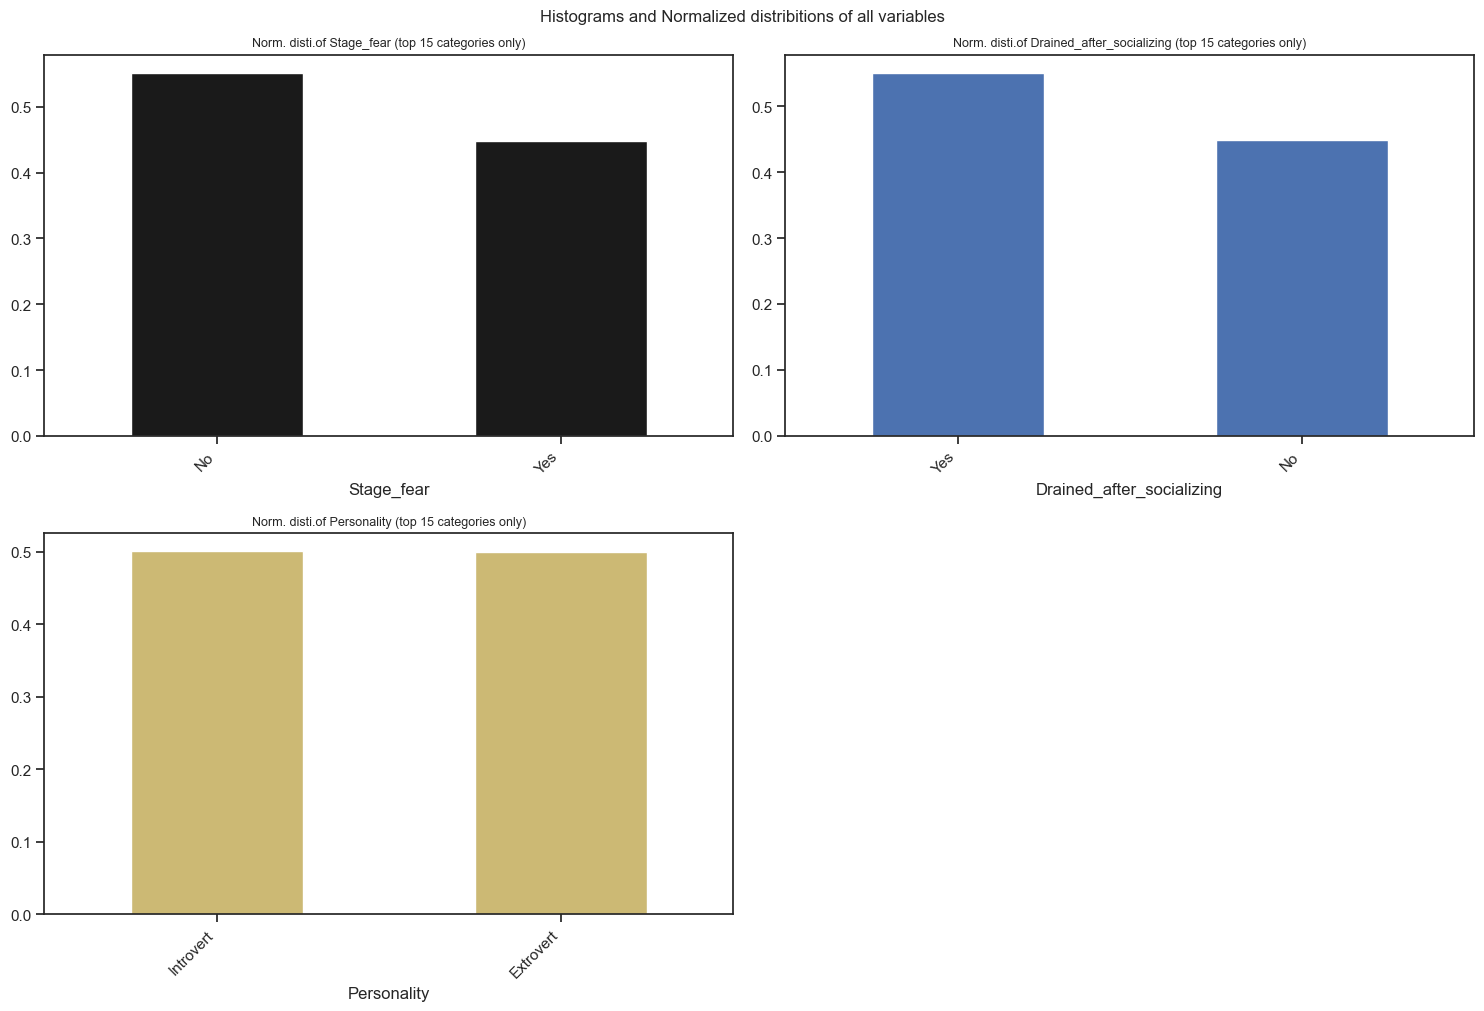

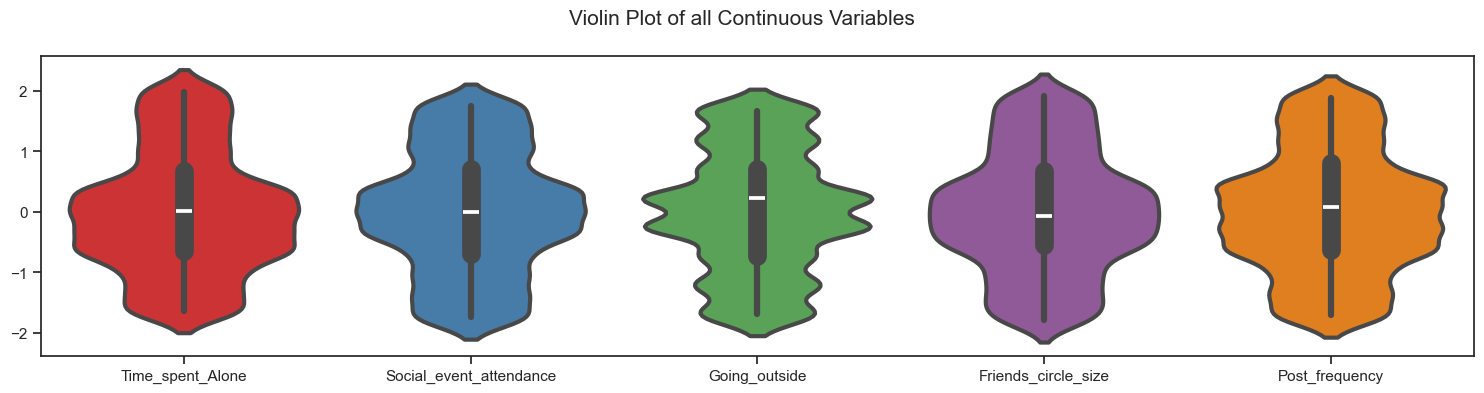

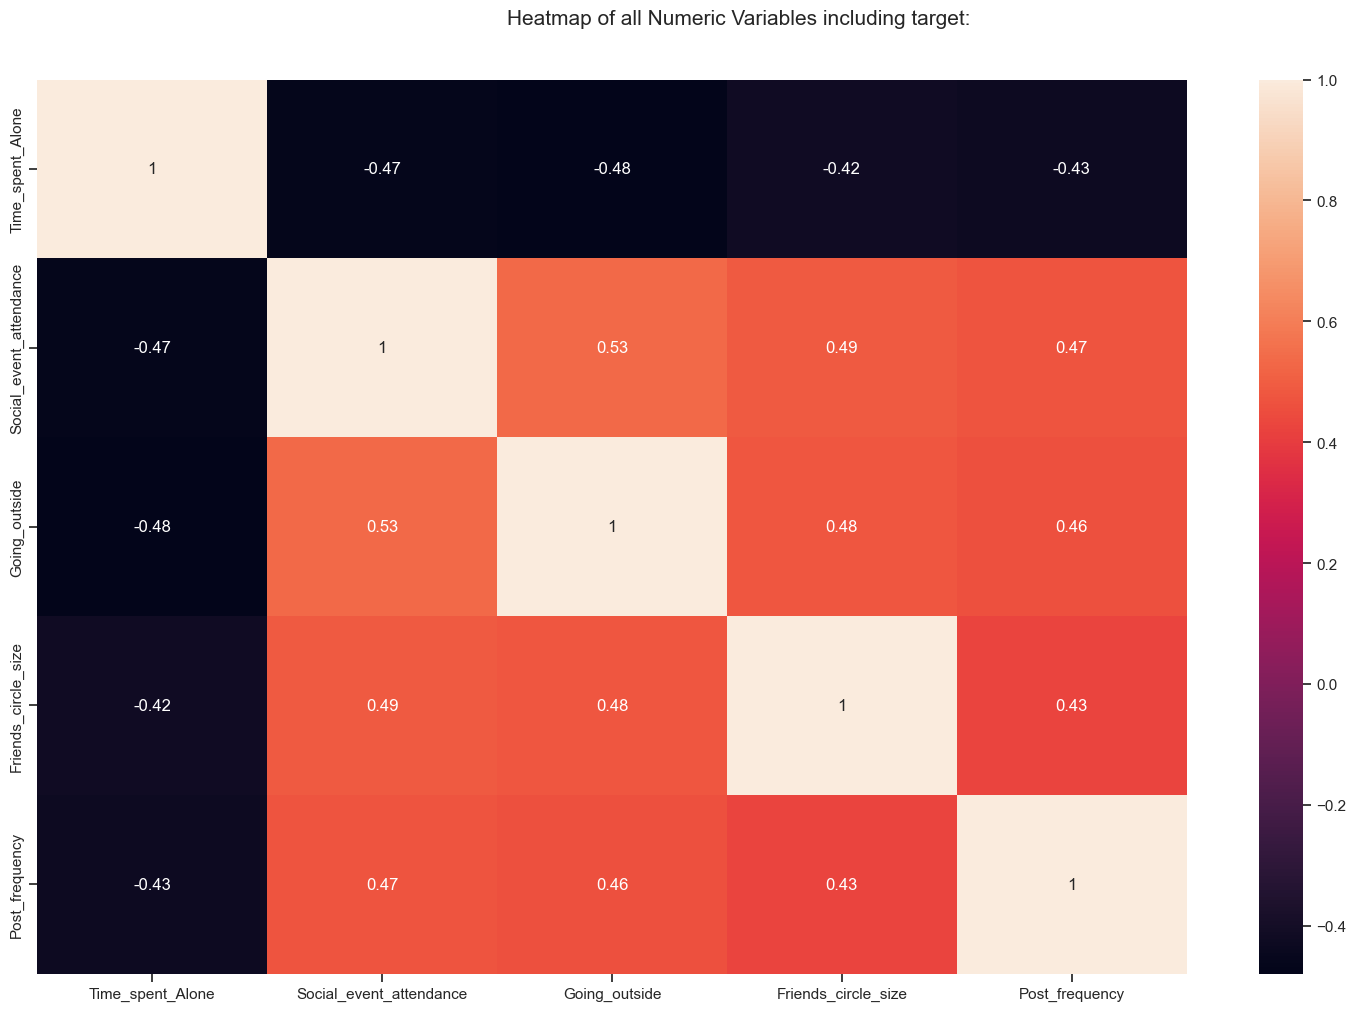

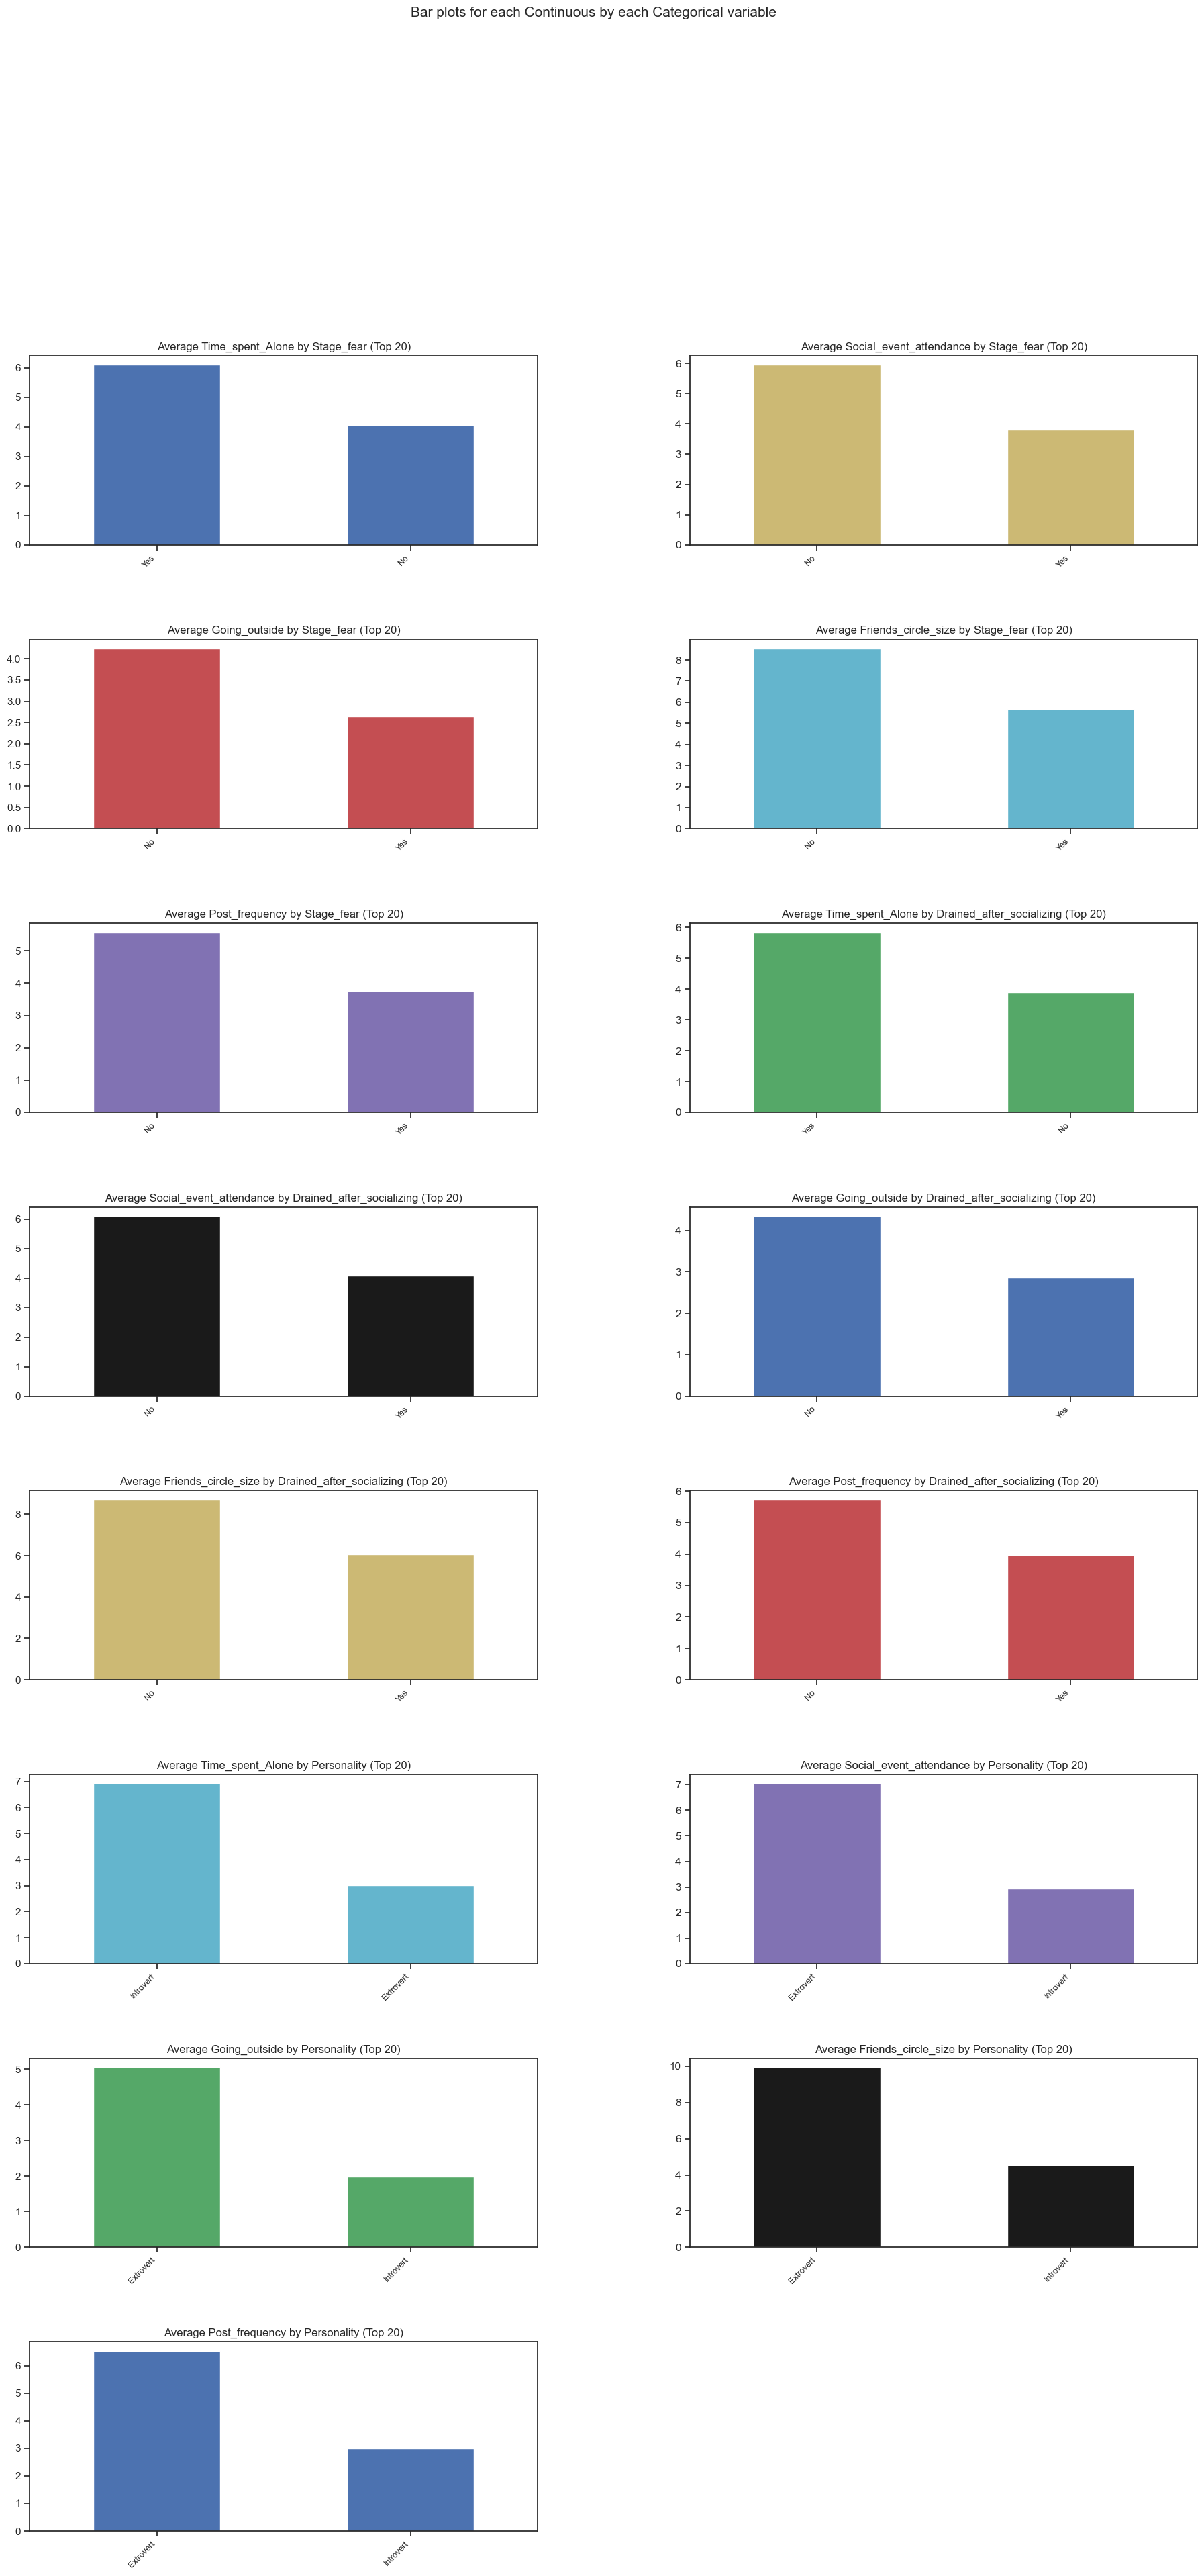

All Plots done
Time to run AutoViz = 4 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [32]:
import matplotlib.pyplot as plt 
%matplotlib inline
eda_report = AV.AutoViz("personality_dataset.csv")

In [33]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [34]:
scaler = StandardScaler()
label = LabelEncoder()

In [35]:
cat_cols = df.select_dtypes(include=['object']).columns

In [36]:
cat_cols

Index(['Stage_fear', 'Drained_after_socializing', 'Personality'], dtype='object')

In [37]:
for col in cat_cols : 
    df[col] = label.fit_transform(df[col])

In [38]:
X = df.drop('Personality',axis=1)
y = df['Personality']

In [49]:
X = scaler.fit_transform(X)

In [50]:
X

array([[-0.64905994,  1.10957055,  0.35106317, ..., -1.10688262,
         1.66777954,  0.08640006],
       [-0.97869932, -0.90124959,  1.04983539, ..., -1.10688262,
        -0.06258994,  1.16550157],
       [-1.3083387 , -0.90124959,  1.3992215 , ..., -1.10688262,
         0.43180134, -0.63300094],
       ...,
       [-0.97869932, -0.90124959,  0.70044928, ..., -1.10688262,
         0.92619262, -0.63300094],
       [-0.97869932,  1.10957055,  1.3992215 , ..., -1.10688262,
         1.91497517,  0.80580107],
       [-0.31942056,  1.10957055,  0.35106317, ..., -1.10688262,
         1.17338826, -0.63300094]])

In [52]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report 

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False,eval_metric = 'logloss',random_state=42)

In [56]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,use_label_encoder,False
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [60]:
rf_pred = rf.predict(X_test)

In [61]:
xgb_pred = xgb.predict(X_test)

In [64]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

In [65]:
evaluate_model("Random Forest (Bagging)", y_test, rf_pred)
evaluate_model("XGBoost (Boosting)", y_test, xgb_pred)


Random Forest (Bagging) Performance:
Accuracy: 0.997
Precision: 1.0
Recall: 0.9939516129032258
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       504
           1       1.00      0.99      1.00       496

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


XGBoost (Boosting) Performance:
Accuracy: 0.996
Precision: 1.0
Recall: 0.9919354838709677
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       504
           1       1.00      0.99      1.00       496

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [66]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [67]:
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(X)

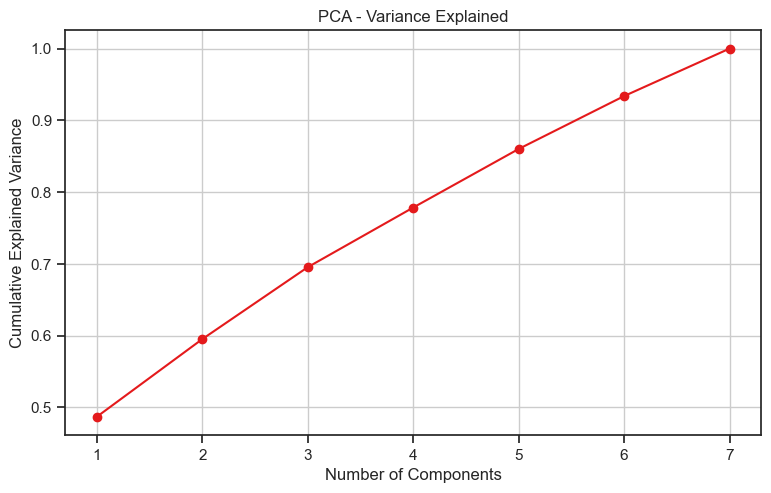

In [69]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_.cumsum(),marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Variance Explained")
plt.grid(True)
plt.show()

In [73]:
print("Original shape:", X.shape)
print("Reduced shape after PCA:", x_pca.shape)

# Train/test split again with PCA-transformed features
X_train_pca, X_test_pca, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

# Re-train models
rf_model_pca = RandomForestClassifier(random_state=42)
xgb_model_pca = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rf_model_pca.fit(X_train_pca, y_train)
xgb_model_pca.fit(X_train_pca, y_train)

# Predictions and evaluation
rf_pred_pca = rf_model_pca.predict(X_test_pca)
xgb_pred_pca = xgb_model_pca.predict(X_test_pca)

evaluate_model("Random Forest with PCA", y_test, rf_pred_pca)
evaluate_model("XGBoost with PCA", y_test, xgb_pred_pca)

Original shape: (5000, 7)
Reduced shape after PCA: (5000, 7)

Random Forest with PCA Performance:
Accuracy: 0.994
Precision: 0.9959514170040485
Recall: 0.9919354838709677
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       504
           1       1.00      0.99      0.99       496

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


XGBoost with PCA Performance:
Accuracy: 0.992
Precision: 0.9959349593495935
Recall: 0.9879032258064516
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       504
           1       1.00      0.99      0.99       496

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [74]:
import pickle 

In [76]:
with open("persoanlity_model.pkl",'wb') as f:
    pickle.dump(xgb,f)

In [77]:
with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

In [79]:
with open("pca.pkl","wb") as f:
    pickle.dump(pca,f)

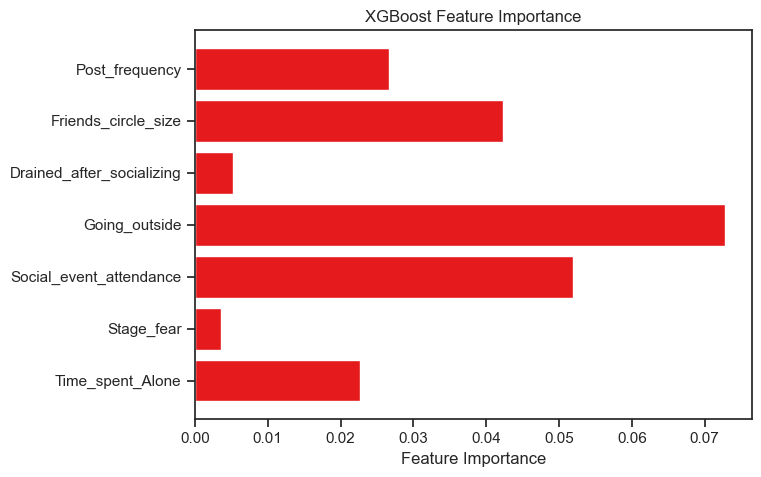

In [81]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

result = permutation_importance(xgb, X, y, n_repeats=10, random_state=42)
importance = result.importances_mean

# Plot
plt.barh(df.drop('Personality', axis=1).columns, importance)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()
